### 아이디어 1 파일럿 — 유전자 발현으로 CRISPR 의존성을 예측할 수 있는가


- 모델 수식은 [`src/models/`](../src/models/) 에 있고 여기서는 불러다 씁니다. 양쪽이 갈라지지 않게 하기 위해서입니다.
- 실행: 위에서부터 순서대로. 전체 1분 이내 (계산 자체는 약 12초).
- 결과 수치는 [Q4 문서](../docs/research/2026-08-13/depmap_gpt_qna/lkeonwoo94.md) 에 실린 값과 같습니다.




### 0. 배경 — 우리가 풀려는 문제

**CRISPR 의존성(gene effect)** 은 이런 실험의 결과입니다.

1. 암세포주를 배양한다 (예: 대장암 세포주 HT-29).
2. CRISPR 로 유전자 하나를 **망가뜨린다**.
3. 세포가 얼마나 죽는지 센다.

많이 죽으면 그 세포주는 그 유전자에 **의존한다**고 말합니다. 값은 이렇게 읽습니다.

| 값 | 의미 |
|---|---|
| `0` 근처 | 망가뜨려도 멀쩡 |
| `-1` | 거의 모든 세포가 필요로 하는 유전자만큼 죽음 |
| 더 작은 음수 | 그 유전자에 더 강하게 의존 |

이 실험은 비싸고 오래 걸립니다. 그래서 **더 싼 측정값(유전자 발현)으로 이걸 예측할 수 있을까?** 가 우리 질문입니다.
된다면 "이 암에는 이 유전자가 약점" 을 실험 없이 좁힐 수 있습니다.

### 1. 준비

`src/` 를 import 할 수 있도록 저장소 최상위를 경로에 넣습니다.

In [12]:
import sys, time
from pathlib import Path

import numpy as np
import pandas as pd

# 노트북이 어디서 실행되든 저장소 최상위를 찾아 경로에 추가
here = Path.cwd()
repo = next(p for p in [here, *here.parents] if (p / "src").is_dir())
sys.path.insert(0, str(repo))

from src.preprocessing.depmap_io import load_all
from src.models.ridge import ridge_kernel_cv, ridge_small
from src.models.metrics import pearson_cols
from sklearn.model_selection import StratifiedKFold

SD_CUT  = 0.25                     # 선택적 의존 유전자 기준 (표준편차)
N_FOLDS = 5                        # 교차검증 분할 수
SEED    = 0
ALPHAS  = np.logspace(1, 6, 30)    # 릿지 정규화 강도 후보

print("저장소:", repo)

저장소: /home/kali/adni-shared/AI-bio-proj-team-1


### 2. 데이터 불러오기

세 가지가 필요합니다.

| | 내용 | 역할 |
|---|---|---|
| `gene_effect` | 세포주 × 유전자, CRISPR 의존성 | **정답 (Y)** — 맞혀야 할 값 |
| `expression` | 세포주 × 유전자, 유전자 발현량 | **입력 (X)** — 보고 맞히는 재료 |
| `model` | 세포주 메타데이터 | 암종(lineage) 정보 |

`load_all()` 이 세 테이블을 **같은 세포주 목록으로 정렬**해서 돌려줍니다.
이게 중요한 이유는, 행이 어긋나면 A 세포주의 발현으로 B 세포주의 의존성을 맞히는 꼴이 되기 때문입니다.

In [13]:
t0 = time.time()
d = load_all()
print(f"불러오기 {time.time()-t0:.1f}초\n")

print(f"입력 X  expression   {d.expression.shape[0]:>5}개 세포주 x {d.expression.shape[1]:>6}개 유전자")
print(f"정답 Y  gene_effect  {d.gene_effect.shape[0]:>5}개 세포주 x {d.gene_effect.shape[1]:>6}개 유전자")
print(f"        model        {d.model.shape[0]:>5}개 세포주 x {d.model.shape[1]:>6}개 항목")
print(f"\n행(세포주)이 완전히 같은 순서인가: {d.expression.index.equals(d.gene_effect.index)}")

불러오기 0.2초

입력 X  expression    1140개 세포주 x  19215개 유전자
정답 Y  gene_effect   1140개 세포주 x  18531개 유전자
        model         1140개 세포주 x     48개 항목

행(세포주)이 완전히 같은 순서인가: True


실제 값이 어떻게 생겼는지 봅니다. 유전자 이름은 `심볼 (Entrez ID)` 형식입니다.

In [14]:
print("■ 입력 X — 발현량 log2(TPM+1). 클수록 그 유전자가 많이 켜져 있음")
display(d.expression.shape)
display(d.expression.iloc[:4, :4])

print("■ 정답 Y — CRISPR 의존성. 음수일수록 그 유전자에 의존")
display(d.gene_effect.shape)
display(d.gene_effect.iloc[:4, :4])

■ 입력 X — 발현량 log2(TPM+1). 클수록 그 유전자가 많이 켜져 있음


(1140, 19215)

,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147)
ModelID,,,,
ACH-000001,5.490942,0.0,7.558490,2.306714
ACH-000004,2.385768,0.0,5.594184,2.659886
ACH-000005,2.616852,0.0,5.760024,3.253649
ACH-000007,3.693431,0.0,6.139473,3.419419


■ 정답 Y — CRISPR 의존성. 음수일수록 그 유전자에 의존


(1140, 18531)

,A1BG (1),A1CF (29974),A2M (2),A2ML1 (144568)
ModelID,,,,
ACH-000001,-0.051662,0.082541,0.002830,-0.112791
ACH-000004,0.089047,-0.031396,-0.145920,-0.027774
ACH-000005,-0.060334,0.092245,0.139777,0.133384
ACH-000007,0.016785,-0.054811,0.026886,0.136228


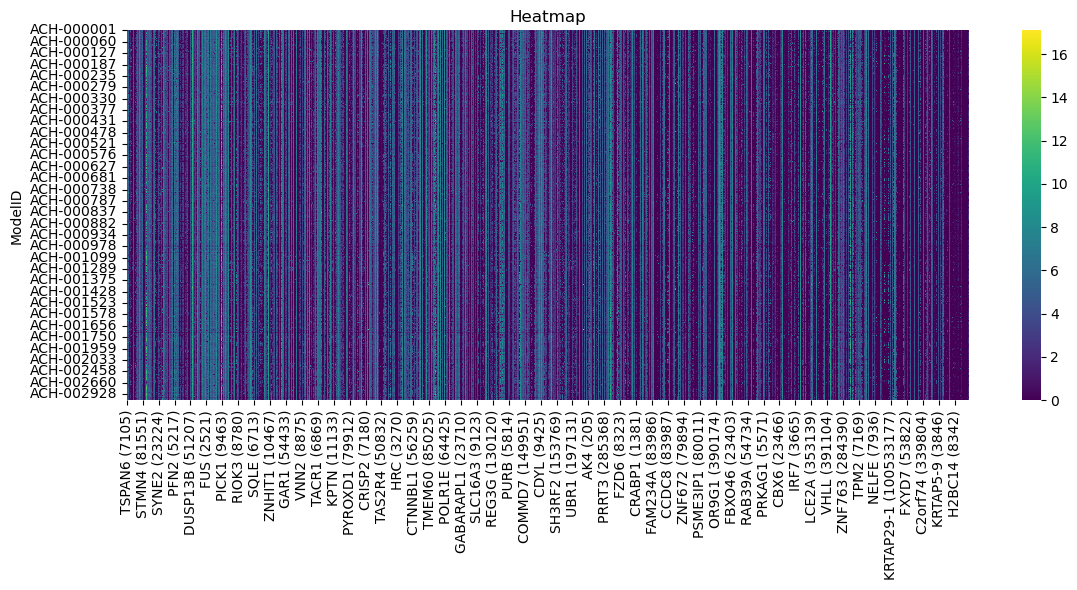

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.heatmap(d.expression, cmap="viridis")
plt.title("Heatmap")
plt.tight_layout()
plt.show()

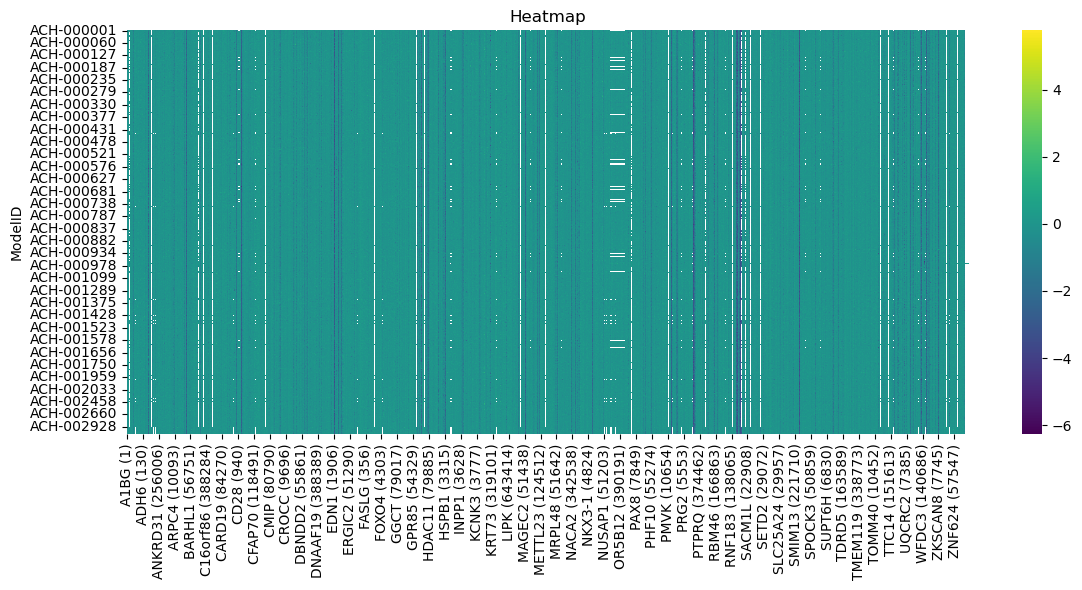

In [10]:
plt.figure(figsize=(12, 6))
sns.heatmap(d.gene_effect, cmap="viridis")
plt.title("Heatmap")
plt.tight_layout()
plt.show()

### 3. 맞힐 유전자 고르기

18,531개 유전자를 전부 예측 대상으로 삼으면 **결과가 거짓으로 좋아 보입니다.** 두 종류를 걸러냅니다.

**① 공통 필수(common essential) 유전자 — 제외**
- 리보솜처럼 어떤 세포든 없으면 죽는 유전자입니다. 모든 세포주에서 값이 똑같이 낮으니
"전부 -1이라고 답해" 만 해도 맞습니다. 예측한 게 아닙니다.

**② 변화가 없는 유전자 — 제외**
- 세포주가 바뀌어도 값이 거의 안 움직이면 맞힐 게 없습니다. 표준편차로 거릅니다.

남는 것이 **선택적 의존(selective dependency)** — 어떤 암에서는 중요하고 어떤 암에서는 안 중요한 유전자입니다.

In [15]:
sd = d.gene_effect.std()
targets = d.selective_targets(sd_cut=SD_CUT)     # common essential 제외 + 표준편차 기준

print(f"전체 유전자                    {d.gene_effect.shape[1]:>6,}")
print(f"  - 공통 필수 제외             {len(d.common_essentials):>6,}")
print(f"  - 표준편차 <= {SD_CUT} 제외      {d.gene_effect.shape[1]-len(d.common_essentials)-len(targets):>6,}")
print(f"= 맞힐 유전자                  {len(targets):>6,}")

전체 유전자                    18,531
  - 공통 필수 제외              1,827
  - 표준편차 <= 0.25 제외      16,039
= 맞힐 유전자                     665


### 4. 채점 방법 정하기

**세포주 단위로 나눠야 합니다.** 훈련에 쓴 세포주가 시험에도 나오면 답을 외운 것이지 예측이 아닙니다.
그래서 세포주를 5덩어리로 나누고, 4덩어리로 배워서 나머지 1덩어리를 맞히기를 5번 반복합니다(5-fold 교차검증).

**암종 비율을 맞춰 나눕니다(층화).** 그냥 무작위로 나누면 폐암이 한쪽에만 몰릴 수 있습니다.
세포주가 5개 미만인 희귀 암종은 나눌 수가 없어 `RARE` 로 묶습니다.

In [16]:
lineage = d.lineage                                   # 암종 (결측은 "Unknown")
counts  = lineage.map(lineage.value_counts())
strat   = lineage.where(counts >= N_FOLDS, "RARE")    # 너무 적은 암종은 한 덩어리로

splits = list(StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED)
              .split(np.zeros(len(d.gene_effect)), strat))

print(f"세포주 {len(d.gene_effect):,}개를 {N_FOLDS}덩어리로 분할\n")
for i, (tr, te) in enumerate(splits, 1):
    print(f"  {i}회차: 학습 {len(tr):>4}개 / 시험 {len(te):>4}개")
print(f"\n암종 {lineage.nunique()}종, 그중 세포주 5개 미만이라 RARE 로 묶인 암종 "
      f"{(strat=='RARE').sum()}개 세포주")

세포주 1,140개를 5덩어리로 분할

  1회차: 학습  912개 / 시험  228개
  2회차: 학습  912개 / 시험  228개
  3회차: 학습  912개 / 시험  228개
  4회차: 학습  912개 / 시험  228개
  5회차: 학습  912개 / 시험  228개

암종 29종, 그중 세포주 5개 미만이라 RARE 로 묶인 암종 8개 세포주


### 5. 비교 대상(베이스라인) 3종

"우리 모델의 상관계수가 0.4다" 는 그 자체로는 좋은지 나쁜지 알 수 없습니다.
**아무것도 안 하는 방법들**과 비교해야 의미가 생깁니다.

| 베이스라인 | 하는 일 | 왜 필요한가 |
|---|---|---|
| **평균** | 유전자별 평균값을 그대로 답한다 | 가장 게으른 답. 이걸 못 이기면 아무 의미 없음 |
| **암종만** | 암종(폐암/대장암…)만 보고 답한다 | "흑색종이면 SOX10 의존" 은 발현을 안 봐도 맞힘. **발현의 공로로 착각하기 쉬운 부분** |
| **자기 발현만** | 그 유전자 자신의 발현량 하나만 본다 | 특징 19,215개가 정말 필요한지 확인 |

세 번째까지 이겨야 "발현 전체를 쓴 보람이 있다" 고 말할 수 있습니다.

#### 준비 — 입력 정리

- 발현은 유전자마다 단위가 달라 **표준화**합니다(평균 0, 표준편차 1).
- 정답에 결측이 약 8% 있습니다. 계산을 행렬로 유지하려고 **적합할 때는 평균으로 채우고,
  채점할 때는 원래 결측을 그대로 제외**합니다. 채운 값을 채점하면 없는 정답을 맞혔다고 하는 셈이니까요.

In [17]:
X = d.expression.values.astype(np.float64)
X = (X - X.mean(0)) / (X.std(0) + 1e-8)               # 표준화

Yraw  = d.gene_effect[targets].values.astype(np.float64)
Yfill = np.where(np.isnan(Yraw), np.nanmean(Yraw, axis=0), Yraw)

lin_oh   = pd.get_dummies(lineage).values.astype(np.float64)   # 암종 원핫
col_of   = {c: i for i, c in enumerate(d.expression.columns)}
self_idx = np.array([col_of.get(g, -1) for g in targets])      # 자기 자신 발현 위치

print(f"X {X.shape}  (표준화 완료)")
print(f"Y {Yraw.shape}  결측 {np.isnan(Yraw).mean()*100:.1f}%")
print(f"암종 원핫 {lin_oh.shape}")
print(f"발현 데이터에 자기 자신이 있는 타깃: {(self_idx>=0).sum()} / {len(targets)}")

X (1140, 19215)  (표준화 완료)
Y (1140, 665)  결측 8.4%
암종 원핫 (1140, 29)
발현 데이터에 자기 자신이 있는 타깃: 665 / 665


#### 눈으로 확인 — 세 입력을 같은 세포주 순서로 나란히

숫자 네 줄로 넘어가기 전에 그림으로 봅니다. 행(세포주)을 **암종끼리 묶어** 정렬했으니
가로줄 무늬가 보이면 그건 "같은 암종끼리 닮았다" 는 뜻입니다.

- **X** 에 가로 띠가 보이면 → 발현에 암종 구조가 들어 있다
- **Y** 에도 같은 위치에 띠가 보이면 → 의존성에도 암종 구조가 있다 (그래서 `암종만` 베이스라인이 필요합니다)
- 오른쪽 계단 무늬는 암종 원핫이 제대로 만들어졌는지 확인용입니다

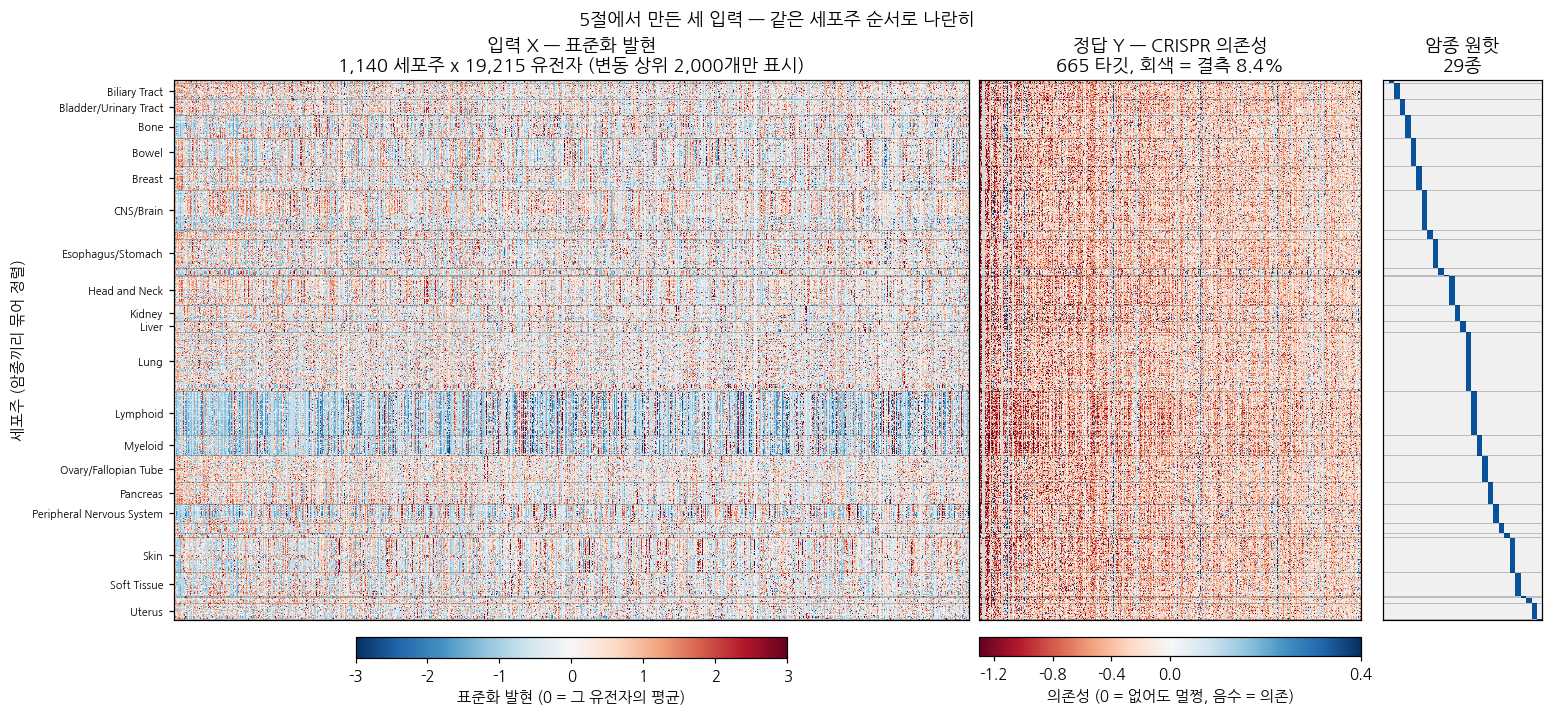

In [18]:
# 세 입력(X, Yraw, lin_oh)을 같은 세포주 순서로 나란히 본다
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.colors import ListedColormap, TwoSlopeNorm

nanum = Path("/usr/share/fonts/truetype/nanum")                 # 한글 폰트
if nanum.exists():
    for f in fm.findSystemFonts(fontpaths=[str(nanum)]):
        fm.fontManager.addfont(f)
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams.update({"axes.unicode_minus": False, "figure.dpi": 110})

N_SHOW = 2000                                    # X 는 열이 19,215개라 일부만 그린다

# 행(세포주)을 암종끼리 붙여 정렬 — 세 그림 모두 같은 행 순서
order   = lineage.reset_index(drop=True).sort_values(kind="stable").index.values
lin_srt = lineage.values[order]
edges   = np.flatnonzero(lin_srt[1:] != lin_srt[:-1]) + 1       # 암종 경계
blocks  = [(s, e) for s, e in zip(np.r_[0, edges], np.r_[edges, len(lin_srt)])]

# 열은 변동이 큰 순서로 정렬 (구조가 보이게)
gx = np.argsort(d.expression.std().values)[::-1][:N_SHOW]       # 발현 변동 상위
gy = np.argsort(d.gene_effect[targets].std().values)[::-1]      # 의존성 변동 상위

cmap_y = plt.get_cmap("RdBu").copy()
cmap_y.set_bad("#d9d9d9")                                       # 결측은 회색

fig, ax = plt.subplots(1, 3, figsize=(14, 6.4), layout="constrained",
                       gridspec_kw={"width_ratios": [5, 2.4, 1]})

im0 = ax[0].imshow(X[np.ix_(order, gx)], aspect="auto", interpolation="nearest",
                   cmap="RdBu_r", vmin=-3, vmax=3)
ax[0].set_title(f"입력 X — 표준화 발현\n{X.shape[0]:,} 세포주 x {X.shape[1]:,} 유전자 "
                f"(변동 상위 {N_SHOW:,}개만 표시)")

im1 = ax[1].imshow(Yraw[np.ix_(order, gy)], aspect="auto", interpolation="nearest",
                   cmap=cmap_y, norm=TwoSlopeNorm(vmin=-1.3, vcenter=0, vmax=0.4))
ax[1].set_title(f"정답 Y — CRISPR 의존성\n{Yraw.shape[1]:,} 타깃, "
                f"회색 = 결측 {np.isnan(Yraw).mean()*100:.1f}%")

ax[2].imshow(lin_oh[order], aspect="auto", interpolation="nearest",
             cmap=ListedColormap(["#f0f0f0", "#08519c"]), vmin=0, vmax=1)
ax[2].set_title(f"암종 원핫\n{lin_oh.shape[1]}종")

for a in ax:
    a.set_xticks([])
    a.set_yticks([])
    for e in edges:                                             # 암종 경계선
        a.axhline(e - .5, color="k", lw=.4, alpha=.35)

big = [(s, e) for s, e in blocks if e - s >= 25]                # 이름은 큰 암종만
ax[0].set_yticks([(s + e) / 2 - .5 for s, e in big])
ax[0].set_yticklabels([lin_srt[s] for s, _ in big], fontsize=7)
ax[0].set_ylabel("세포주 (암종끼리 묶어 정렬)")

fig.colorbar(im0, ax=ax[0], location="bottom", fraction=.04, pad=.03,
             label="표준화 발현 (0 = 그 유전자의 평균)")
fig.colorbar(im1, ax=ax[1], location="bottom", fraction=.08, pad=.03,
             label="의존성 (0 = 없어도 멀쩡, 음수 = 의존)", ticks=[-1.2, -.8, -.4, 0, .4])
fig.suptitle("5절에서 만든 세 입력 — 같은 세포주 순서로 나란히")
plt.show()

### 6. 학습 — 5회차를 돌면서 4가지 방법을 모두 계산

각 회차마다 **시험 세포주는 절대 학습에 쓰지 않습니다.**
결과는 `P[방법]` 에 "그 세포주가 시험 대상이었을 때의 예측값" 으로 채워집니다.

릿지가 왜 빠른지 궁금하면 [`src/models/ridge.py`](../src/models/ridge.py) 에 설명이 있습니다.
요지는 세포주 수(1,140)가 유전자 수(19,215)보다 훨씬 적어서, 큰 쪽이 아니라 **작은 쪽 크기로 계산**할 수 있다는 것입니다.

In [7]:
P = {k: np.full_like(Yraw, np.nan) for k in ("평균", "암종만", "자기발현만", "발현전체(릿지)")}

t0 = time.time()
for i, (tr, te) in enumerate(splits, 1):
    # ① 평균
    P["평균"][te] = Yfill[tr].mean(0)

    # ② 암종만
    P["암종만"][te] = ridge_small(lin_oh[tr], Yfill[tr], lin_oh[te])

    # ③ 자기 자신 발현만 (단순회귀를 전 유전자에 한 번에)
    has = self_idx >= 0
    idx = self_idx[has]
    xtr, xte, ytr = X[tr][:, idx], X[te][:, idx], Yfill[tr][:, has]
    xm, ym = xtr.mean(0), ytr.mean(0)
    beta = ((xtr-xm) * (ytr-ym)).sum(0) / (((xtr-xm)**2).sum(0) + 1e-12)
    P["자기발현만"][np.ix_(te, np.flatnonzero(has))] = (xte - xm) * beta + ym

    # ④ 발현 전체 — 릿지
    P["발현전체(릿지)"][te] = ridge_kernel_cv(X[tr], Yfill[tr], X[te], ALPHAS)
    print(f"  {i}/{N_FOLDS} 회차 완료")

print(f"\n총 {time.time()-t0:.1f}초")

  1/5 회차 완료


  2/5 회차 완료


  3/5 회차 완료


  4/5 회차 완료


  5/5 회차 완료

총 21.4초


### 7. 채점 — 반드시 **유전자마다 따로**

전체를 한 덩어리로 채점하면 안 됩니다. 유전자마다 값의 범위가 다르기 때문에,
"유전자별 평균" 만 답해도 전체 상관이 0.9를 넘습니다. 아무것도 예측하지 못했는데도요.

그래서 유전자 하나를 고정하고 **세포주 축을 따라** 상관계수를 계산합니다. 665개의 점수가 나옵니다.

상관계수 r 은 −1 ~ 1 이고, 클수록 예측이 잘 맞은 것입니다. 0이면 무작위와 같습니다.

In [8]:
R = pd.DataFrame({k: pearson_cols(Yraw, v) for k, v in P.items()}, index=targets)

# 결측이 많아 상관을 낼 수 없는 유전자는 NaN 이 된다. 비율은 채점된 유전자 기준으로 낸다.
n_scored = R["발현전체(릿지)"].notna().sum()
print(f"채점된 유전자 {n_scored:,} / {len(R):,}  "
      f"(나머지 {len(R)-n_scored}개는 결측이 많아 상관을 낼 수 없음)\n")

summary = pd.DataFrame({
    "중앙값 r":   R.median().round(3),
    "r>0.3 비율": (R > 0.3).sum() / R.notna().sum(),
    "r>0.5 개수": (R > 0.5).sum(),
}).round(3)
display(summary)

채점된 유전자 634 / 665  (나머지 31개는 결측이 많아 상관을 낼 수 없음)



,중앙값 r,r>0.3 비율,r>0.5 개수
평균,-0.052,0.000,0
암종만,0.226,0.270,24
자기발현만,0.044,0.077,15
발현전체(릿지),0.404,0.831,124


#### 읽는 법

- **평균**은 중앙값 r 이 0 근처(살짝 음수)입니다. 정상입니다 — 학습에 안 쓴 세포주를 맞히니 평균은 아무 정보가 없습니다.
- **암종만**으로도 꽤 맞습니다. 암종이 실제로 강한 정보라는 뜻이고, 동시에 **여기까지는 발현의 공로가 아니라는** 뜻입니다.
- **자기 발현만**은 생각보다 약합니다. 유전자 하나로는 부족합니다.
- **발현 전체**가 가장 높습니다. 이 차이가 이 프로젝트가 성립하는 근거입니다.

In [9]:
gain = R["발현전체(릿지)"] - R["암종만"]
print(f"발현 전체가 '암종만' 을 이긴 유전자: {(gain>0).sum():,} / {len(R):,}  ({(gain>0).mean()*100:.1f}%)")
print(f"  그중 r 을 0.1 이상 끌어올린 유전자: {(gain>0.1).sum():,}")
print(f"\n■ 가장 잘 예측된 유전자 10개")
display(R.sort_values("발현전체(릿지)", ascending=False).head(10).round(3))

발현 전체가 '암종만' 을 이긴 유전자: 613 / 665  (92.2%)
  그중 r 을 0.1 이상 끌어올린 유전자: 516

■ 가장 잘 예측된 유전자 10개


,평균,암종만,자기발현만,발현전체(릿지)
SOX10 (6663),-0.025,0.686,0.846,0.828
PAX8 (7849),-0.017,0.630,0.642,0.817
EBF1 (1879),-0.033,0.592,0.518,0.802
MYB (4602),-0.058,0.690,0.661,0.769
TP63 (8626),-0.049,0.496,0.671,0.760
IRF4 (3662),-0.056,0.644,0.763,0.753
FERMT2 (10979),-0.033,0.571,0.532,0.741
POU2AF1 (5450),-0.012,0.572,0.659,0.737
HNF1B (6928),-0.043,0.418,0.754,0.727
CTNNB1 (1499),-0.034,0.576,0.199,0.723


### 8. 분포로 보기

숫자 몇 개보다 분포가 정직합니다. **잘 맞는 유전자는 소수** 라는 것이 이 분야의 정상적인 결과입니다.

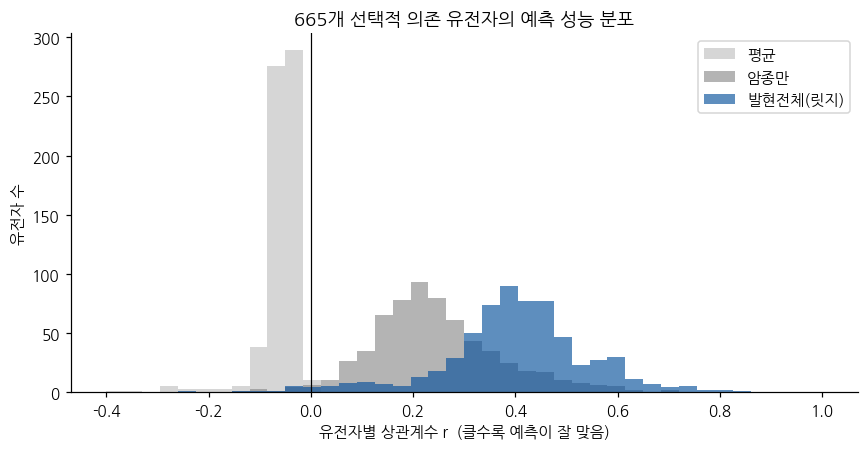

In [10]:
import matplotlib
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

nanum = Path("/usr/share/fonts/truetype/nanum")          # 한글 폰트
if nanum.exists():
    for f in fm.findSystemFonts(fontpaths=[str(nanum)]):
        fm.fontManager.addfont(f)
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams.update({"axes.unicode_minus": False, "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False})

fig, ax = plt.subplots(figsize=(8, 4.2))
for name, color in [("평균", "#c0c0c0"), ("암종만", "#8c8c8c"),
                    ("발현전체(릿지)", "#08519c")]:
    ax.hist(R[name].dropna(), bins=40, range=(-0.4, 1.0), alpha=.65,
            label=name, color=color)
ax.axvline(0, color="k", lw=.8)
ax.set_xlabel("유전자별 상관계수 r  (클수록 예측이 잘 맞음)")
ax.set_ylabel("유전자 수")
ax.set_title(f"{len(R):,}개 선택적 의존 유전자의 예측 성능 분포")
ax.legend()
plt.tight_layout()
plt.show()

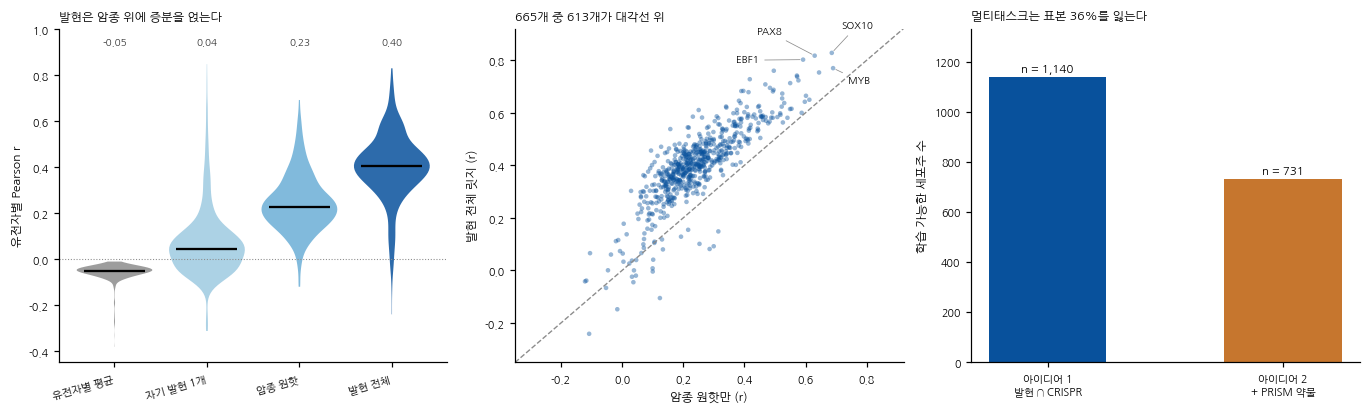

/home/kali/adni-shared/AI-bio-proj-team-1/results/figures/q4_d1_baseline_comparison.png  (n1=1140, n2=731, genes=665)


In [1]:
"""Q4 D-1 그림 — 발현 기반 예측 vs 베이스라인 3종.

`pilot_idea1_ridge.py` 가 만든 유전자별 점수와 raw 데이터를 읽어
`results/figures/q4_d1_baseline_comparison.png` 를 생성한다.

    python3 scripts/pilot_idea1_ridge.py   # 먼저 실행 (점수 생성)
    python3 scripts/plot_q4_d1.py

파일명 규칙은 results/figures/README.md 참고.
"""
from pathlib import Path

import matplotlib
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

here = Path.cwd()
ROOT = Path(here).resolve().parent
RAW = Path("/home/kali/adni-shared/raw")
TABLES = ROOT / "results" / "tables"
FIGURES = ROOT / "results" / "figures"
OUT = FIGURES / "q4_d1_baseline_comparison.png"

GREY = "#8c8c8c"
BLUE = "#08519c"
ORANGE = "#c6762e"


def use_korean_font():
    """시스템 나눔고딕을 등록한다. 없으면 기본 폰트로 진행(한글 깨짐)."""
    nanum = Path("/usr/share/fonts/truetype/nanum")
    if nanum.exists():
        for p in fm.findSystemFonts(fontpaths=[str(nanum)]):
            fm.fontManager.addfont(p)
        plt.rcParams["font.family"] = "NanumGothic"
    plt.rcParams.update({
        "axes.unicode_minus": False, "figure.dpi": 110,
        "axes.spines.top": False, "axes.spines.right": False,
        "font.size": 8, "axes.titlesize": 8, "axes.labelsize": 8,
        "xtick.labelsize": 7, "ytick.labelsize": 7,
    })


def sample_sizes():
    """아이디어 1·2 의 학습 가능 세포주 수를 raw 에서 직접 센다."""
    ge = pd.read_csv(RAW / "DepMap" / "CRISPRGeneEffect.csv", index_col=0, usecols=[0])
    ex = pd.read_csv(RAW / "DepMap" / "OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv",
                     usecols=["ModelID", "IsDefaultEntryForModel"])
    ex = ex[ex["IsDefaultEntryForModel"] == "Yes"]
    n1 = set(ge.index) & set(ex["ModelID"])

    prism = pd.read_csv(
        RAW / "PRISM_Repurposing_24Q2" /
        "Repurposing_Public_24Q2_Extended_Primary_Data_Matrix.csv",
        index_col=0, nrows=1)
    # 이 행렬은 화합물 x 세포주 방향이라 열이 ModelID 다
    return len(n1), len(n1 & set(prism.columns))


use_korean_font()
gs = pd.read_csv(TABLES / "pilot_idea1_ridge_gene_scores.csv")
n1, n2 = sample_sizes()

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8))

# A — 베이스라인별 유전자 r 분포
ax = axes[0]
series = [("r_mean", "유전자별 평균", GREY), ("r_self", "자기 발현 1개", "#9ecae1"),
            ("r_lineage", "암종 원핫", "#6baed6"), ("r_ridge", "발현 전체", BLUE)]
for i, (key, label, color) in enumerate(series):
    v = gs[key].dropna().values
    for body in ax.violinplot([v], positions=[i], widths=0.82,
                                showextrema=False)["bodies"]:
        body.set_facecolor(color)
        body.set_alpha(0.85)
        body.set_edgecolor("none")
    ax.hlines(np.median(v), i - 0.33, i + 0.33, color="black", lw=1.5, zorder=5)
    ax.text(i, 0.93, f"{np.median(v):.2f}", ha="center", fontsize=6.5, color="#333333")
ax.set_xticks(range(len(series)))
ax.set_xticklabels([s[1] for s in series], rotation=16, ha="right")
ax.axhline(0, color=GREY, lw=0.7, ls=":")
ax.set_ylim(-0.45, 1.0)
ax.set_ylabel("유전자별 Pearson r")
ax.set_title("발현은 암종 위에 증분을 얹는다", loc="left")

# B — 릿지 vs 암종 베이스라인
ax = axes[1]
ax.scatter(gs.r_lineage, gs.r_ridge, s=9, color=BLUE, alpha=0.42, edgecolor="none")
lim = [-0.35, 0.92]
ax.plot(lim, lim, color=GREY, lw=0.9, ls="--", zorder=1)
ax.set_xlim(lim)
ax.set_ylim(lim)
offsets = {"PAX8": (-38, 14), "SOX10": (6, 16), "EBF1": (-44, -2), "MYB": (10, -10)}
for _, row in gs.head(4).iterrows():
    name = row.gene.split(" (")[0]
    ax.annotate(name, (row.r_lineage, row.r_ridge), fontsize=6.5,
                xytext=offsets.get(name, (6, 6)), textcoords="offset points",
                arrowprops=dict(arrowstyle="-", lw=0.5, color=GREY))
ax.set_xlabel("암종 원핫만 (r)")
ax.set_ylabel("발현 전체 릿지 (r)")
ax.set_title(f"{len(gs)}개 중 {int((gs.gain_over_lineage > 0).sum())}개가 대각선 위",
                loc="left")

# C — 멀티태스크 확장 시 표본 손실
ax = axes[2]
values = [n1, n2]
ax.bar(["아이디어 1\n발현 ∩ CRISPR", "아이디어 2\n+ PRISM 약물"], values,
        color=[BLUE, ORANGE], width=0.5)
for i, v in enumerate(values):
    ax.text(i, v + 20, f"n = {v:,}", ha="center", fontsize=7.5)
ax.set_ylabel("학습 가능한 세포주 수")
ax.set_ylim(0, max(values) * 1.17)
ax.set_title(f"멀티태스크는 표본 {1 - n2 / n1:.0%}를 잃는다", loc="left")

fig.tight_layout()
# fig.savefig(OUT, dpi=300, bbox_inches="tight")
plt.show()
print(f"{OUT}  (n1={n1}, n2={n2}, genes={len(gs)})")

## 9. 정리

**결론: 유전자 발현만으로 CRISPR 의존성 예측이 됩니다.** 추가 데이터(변이·copy number) 없이도 성립합니다.

다만 이렇게 읽어야 합니다.

- **모든 유전자가 예측되는 건 아닙니다.** 665개 중 일부만 잘 맞습니다. 그게 실패가 아니라,
  **"어떤 유전자가 예측 가능한가" 를 찾아내는 것 자체가 결과물**입니다.
- **암종만으로 맞는 부분을 빼고 봐야 합니다.** 발현이 그 위에 얹어주는 증분이 진짜 기여입니다.

### 이 노트북에서 조심한 것 4가지

1. 채점은 **유전자별로** (전체 한 덩어리로 하면 0.9가 그냥 나옴)
2. 분할은 **세포주 단위로** (같은 세포주가 학습·시험에 동시에 들어가면 누출)
3. **공통 필수 유전자 제외** (안 빼면 성능이 부풀려짐)
4. **암종 베이스라인과 비교** (발현의 공로를 착각하지 않기 위해)

### 더 볼 것

- 같은 계산의 스크립트판: [`scripts/pilot_idea1_ridge.py`](../scripts/pilot_idea1_ridge.py)
- 릿지가 왜 빠른지: [`src/models/ridge.py`](../src/models/ridge.py)
- Elastic Net 판(더 느리지만 어떤 유전자가 기여했는지 보임): [`scripts/pilot_idea1_enet.py`](../scripts/pilot_idea1_enet.py)
- 데이터 설명서: [`docs/depmap/`](../docs/depmap/README.md)